# EDA e amostragem — RSNA Bone Age

Radiografias PNG e rótulos (`id`, `boneage` em meses, `male`) obtidos de `kmader/rsna-bone-age` via KaggleHub. Execute todas as células em uma sessão limpa do Google Colab. Os dados brutos não são incluídos no Git.


In [1]:
!git clone --depth 1 --branch feature/carlos-data-audit https://github.com/RaulFH0/tp1-e2-bone-age.git
%cd /content/tp1-e2-bone-age
!python -m pip install -q pandas Pillow
!python -m unittest discover -s tests -v

Cloning into 'tp1-e2-bone-age'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 11 (delta 0), reused 9 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 9.03 KiB | 9.03 MiB/s, done.
/content/tp1-e2-bone-age
test_rejects_duplicate_image_ids_before_a_split (test_data_audit.DatasetAuditTests.test_rejects_duplicate_image_ids_before_a_split) ... ok
test_reports_missing_image_and_does_not_invent_patient_groups (test_data_audit.DatasetAuditTests.test_reports_missing_image_and_does_not_invent_patient_groups) ... ok
test_reports_patient_group_column_when_present (test_data_audit.DatasetAuditTests.test_reports_patient_group_column_when_present) ... ok

----------------------------------------------------------------------
Ran 3 tests in 2.111s

OK


In [4]:
!python -m pip install -q kagglehub

import kagglehub
import pandas as pd
from pathlib import Path

csv_path = Path(kagglehub.dataset_download(
    "kmader/rsna-bone-age",
    path="boneage-training-dataset.csv",
))
tabela = pd.read_csv(csv_path)

print("Arquivo:", csv_path)
print("Linhas e colunas:", tabela.shape)
print("Colunas:", tabela.columns.tolist())
print(tabela.head(2).to_string(index=False))

100%|██████████| 180k/180k [00:00<00:00, 50.6MB/s]

Arquivo: /root/.cache/kagglehub/datasets/kmader/rsna-bone-age/versions/2/boneage-training-dataset.csv
Linhas e colunas: (12611, 3)
Colunas: ['id', 'boneage', 'male']
  id  boneage  male
1377      180 False
1378       12 False


In [5]:
import shutil
from pathlib import Path
import kagglehub

livre_gib = shutil.disk_usage("/content").free / 2**30
print(f"Espaço livre: {livre_gib:.1f} GiB")
if livre_gib < 30:
    raise RuntimeError("Espaço insuficiente para baixar e extrair as imagens com segurança.")

imagens = Path(kagglehub.dataset_download(
    "kmader/rsna-bone-age",
    path="boneage-training-dataset",
    output_dir="/content/tp1-e2-bone-age/data/raw",
))

pngs = list(imagens.rglob("*.png"))
print("Pasta retornada:", imagens)
print("Quantidade de PNG:", len(pngs))
print("Exemplo:", pngs[0] if pngs else "nenhuma imagem encontrada")

Espaço livre: 87.4 GiB
Using Colab cache for faster access to the 'rsna-bone-age' dataset.
Pasta retornada: /kaggle/input/rsna-bone-age/boneage-training-dataset
Quantidade de PNG: 12611
Exemplo: /kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/9273.png


In [6]:
import json
import subprocess
import sys
from pathlib import Path

pasta_imagens = imagens / "boneage-training-dataset"
relatorio = Path("/content/tp1-e2-bone-age/results/data_audit.json")

subprocess.run([
    sys.executable, "src/00_audit_data.py",
    "--csv", str(csv_path),
    "--images-dir", str(pasta_imagens),
    "--out", str(relatorio),
], check=True)

dados = json.loads(relatorio.read_text(encoding="utf-8"))
print("Rótulos:", dados["n_rows"])
print("Imagens encontradas:", dados["images"]["found"])
print("Imagens ausentes:", dados["images"]["missing"])
print("Agrupamento por paciente:", dados["patient_grouping"])
print("Idades (meses):", dados["age_months"])
print("Sexo:", dados["sex_counts"])

Rótulos: 12611
Imagens encontradas: 12611
Imagens ausentes: 0
Agrupamento por paciente: {'status': 'not_verifiable', 'note': 'O id da imagem/exame não comprova identidade única do paciente; não declarar partição por paciente sem uma chave verificável.'}
Idades (meses): {'minimum': 1.0, 'median': 132.0, 'maximum': 228.0}
Sexo: {'female': 5778, 'male': 6833}


## Auditoria, distribuição e amostra

Auditoria observada: 12.611 rótulos, 12.611 PNG presentes, nenhuma imagem ausente. Sem chave verificável de paciente, não é possível afirmar que futuras partições não compartilhem pacientes.

A amostra usa 4.000 imagens, semente 42 e estratos proporcionais de idade óssea (0–5, 6–10, 11–15 e 16–19 anos) e sexo. A faixa de 16–19 anos inclui apenas 34 meninas na amostra; analisar esse subgrupo com cautela. Os exemplos de imagem mostram variações de brilho, enquadramento e marcadores.


Idade óssea por faixa:
boneage
0–5 anos      1332
6–10 anos     4166
11–15 anos    6595
16–19 anos     518

Sexo:
male
Masculino    6833
Feminino     5778


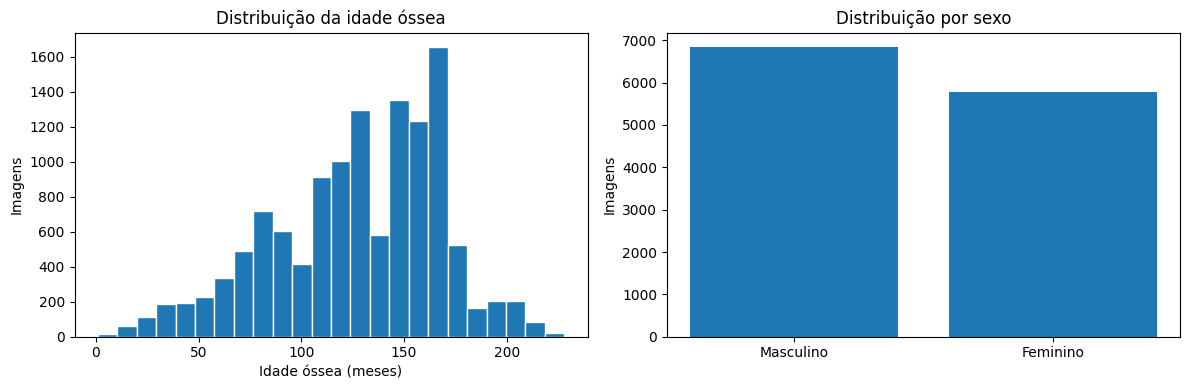

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

eda = pd.read_csv(csv_path)

faixas = pd.cut(
    eda["boneage"],
    bins=[0, 72, 132, 192, 240],
    right=False,
    labels=["0–5 anos", "6–10 anos", "11–15 anos", "16–19 anos"]
)

print("Idade óssea por faixa:")
print(faixas.value_counts().sort_index().to_string())

print("\nSexo:")
print(eda["male"].map({False: "Feminino", True: "Masculino"}).value_counts().to_string())

fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

eixos[0].hist(eda["boneage"], bins=24, edgecolor="white")
eixos[0].set(title="Distribuição da idade óssea",
             xlabel="Idade óssea (meses)", ylabel="Imagens")

contagem_sexo = eda["male"].map({False: "Feminino", True: "Masculino"}).value_counts()
eixos[1].bar(contagem_sexo.index, contagem_sexo.values)
eixos[1].set(title="Distribuição por sexo", ylabel="Imagens")

plt.tight_layout()
plt.show()

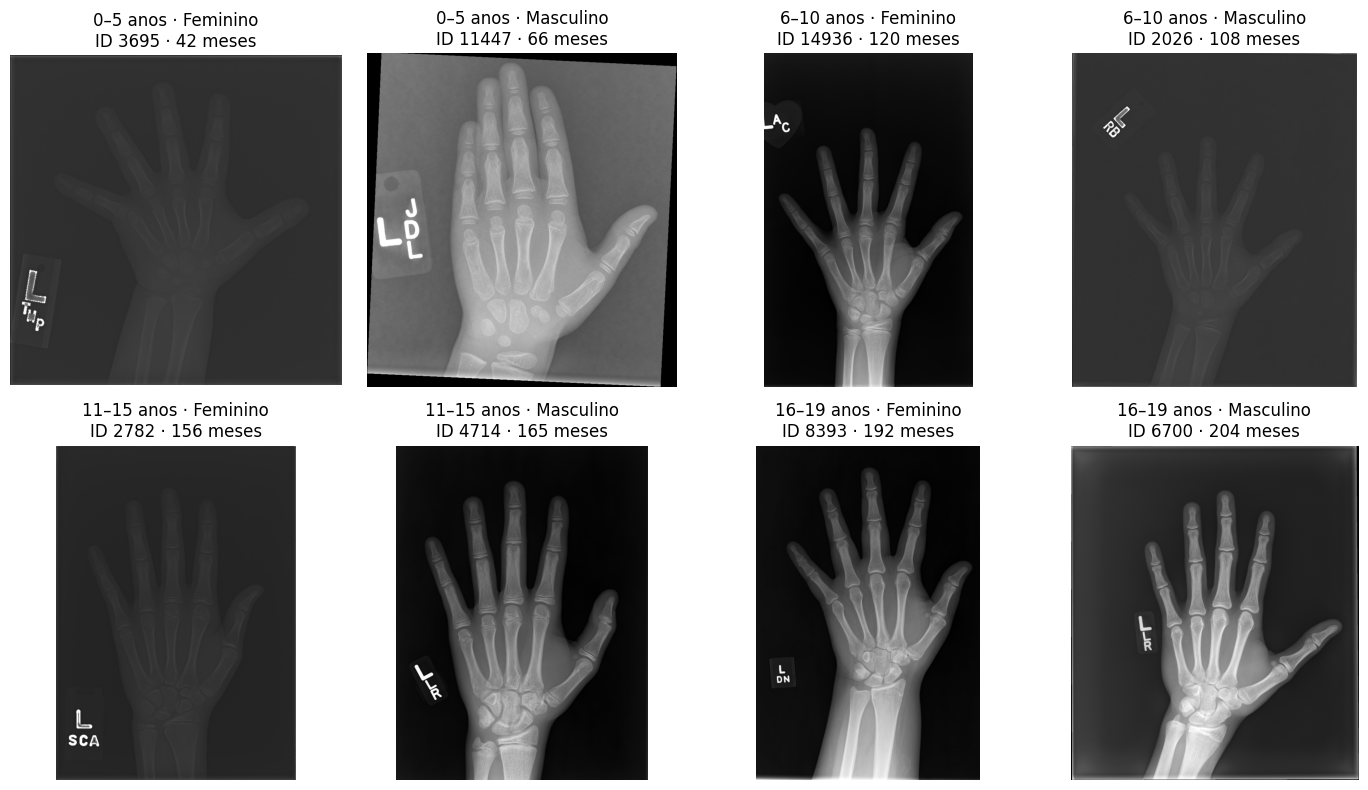

In [9]:
from PIL import Image

exemplos = (
    eda.assign(faixa=faixas)
       .groupby(["faixa", "male"], observed=True)
       .sample(n=1, random_state=42)
       .sort_values(["faixa", "male"])
)

fig, eixos = plt.subplots(2, 4, figsize=(14, 8))

for eixo, (_, linha) in zip(eixos.flat, exemplos.iterrows()):
    caminho = pasta_imagens / f"{int(linha['id'])}.png"
    with Image.open(caminho) as imagem:
        eixo.imshow(imagem.convert("L"), cmap="gray")
    sexo = "Masculino" if linha["male"] else "Feminino"
    eixo.set_title(f"{linha['faixa']} · {sexo}\nID {linha['id']} · {linha['boneage']} meses")
    eixo.axis("off")

plt.tight_layout()
plt.show()

In [10]:
from pathlib import Path
from sklearn.model_selection import train_test_split

base = eda.sort_values("id").reset_index(drop=True).copy()
base["faixa"] = pd.cut(
    base["boneage"],
    bins=[0, 72, 132, 192, 240],
    right=False,
    labels=["0–5", "6–10", "11–15", "16–19"]
)
base["estrato"] = base["faixa"].astype(str) + "_" + base["male"].astype(str)

amostra, _ = train_test_split(
    base,
    train_size=4000,
    random_state=42,
    stratify=base["estrato"]
)
amostra = amostra.sort_values("id")

print("Total selecionado:", len(amostra))
print("\nContagem por faixa e sexo:")
print(pd.crosstab(
    amostra["faixa"],
    amostra["male"].map({False: "Feminino", True: "Masculino"})
).to_string())

saida = Path("data/splits/sample_ids.csv")
saida.parent.mkdir(parents=True, exist_ok=True)
amostra[["id"]].to_csv(saida, index=False)
print("\nIDs salvos em:", saida)

Total selecionado: 4000

Contagem por faixa e sexo:
male   Feminino  Masculino
faixa                     
0–5         228        195
6–10        789        532
11–15       781       1311
16–19        34        130

IDs salvos em: data/splits/sample_ids.csv
